# Interpretable CNN Models
## Lab 2: Transfer Learning, Feature Understanding, Explainability, and Robustness (CNN-only)

### Learning Outcomes
By the end of this lab, you will be able to:
1. Train a **modern CNN (ConvNeXt)** using transfer learning.
2. Inspect **what early/mid layers detect** (flat regions, edges, corners).
3. Explain predictions using **Grad-CAM** heatmaps.
4. Evaluate **robustness** under noise, blur, occlusion, and color shift.
5. Diagnose misclassifications using **failure analysis**.


# Imports & Reproducibility Configuration

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DATA_DIR = "/kaggle/input/pumpkin/Original/Original"
assert os.path.isdir(DATA_DIR), f"Dataset directory not found: {DATA_DIR}"
print("DATA_DIR:", DATA_DIR)
print("Subfolders:", os.listdir(DATA_DIR))


DEVICE: cuda
DATA_DIR: /kaggle/input/pumpkin/Original/Original
Subfolders: ['Powdery Mildew', 'Bacterial Leaf Spot', 'Healthy Leaf', 'Downy Mildew', 'Mosaic Disease']


# Dataset, Splits, Transforms, DataLoaders

In [2]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
EPOCHS = 25

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

base_ds = datasets.ImageFolder(DATA_DIR)
class_names = base_ds.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Num classes:", num_classes)
print("Total images:", len(base_ds))

val_ratio = 0.2
val_len = int(len(base_ds) * val_ratio)
train_len = len(base_ds) - val_len

g = torch.Generator().manual_seed(SEED)
train_base, val_base = random_split(base_ds, [train_len, val_len], generator=g)

class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

train_ds = TransformSubset(train_base, train_tfms)
val_ds   = TransformSubset(val_base, val_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("Train size:", len(train_ds), "Val size:", len(val_ds))


Classes: ['Bacterial Leaf Spot', 'Downy Mildew', 'Healthy Leaf', 'Mosaic Disease', 'Powdery Mildew']
Num classes: 5
Total images: 2000
Train size: 1600 Val size: 400


##  Quick sanity check: visualize a batch (denormalized)

We display a small training batch to verify:
- Data pipeline works
- Images are sensible
- Labels align with class folders


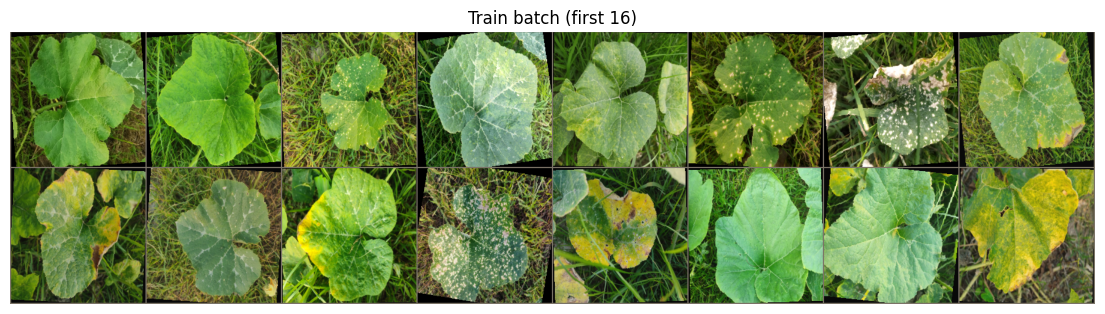

Labels: ['Healthy Leaf', 'Healthy Leaf', 'Powdery Mildew', 'Bacterial Leaf Spot', 'Powdery Mildew', 'Powdery Mildew', 'Powdery Mildew', 'Downy Mildew', 'Downy Mildew', 'Bacterial Leaf Spot', 'Downy Mildew', 'Powdery Mildew', 'Downy Mildew', 'Healthy Leaf', 'Healthy Leaf', 'Mosaic Disease']


In [3]:
MEAN = np.array(IMAGENET_MEAN, dtype=np.float32)
STD  = np.array(IMAGENET_STD, dtype=np.float32)

def denorm(t):
    x = t.detach().cpu().numpy().transpose(1,2,0)
    x = (x * STD) + MEAN
    return np.clip(x, 0, 1)

xb, yb = next(iter(train_loader))
grid = make_grid(xb[:16], nrow=8)

plt.figure(figsize=(14,6))
plt.imshow(denorm(grid))
plt.axis("off")
plt.title("Train batch (first 16)")
plt.show()

print("Labels:", [class_names[i] for i in yb[:16].tolist()])


# Training Utilities

We implement:
- One epoch training
- Validation evaluation
- Full training loop (`fit`)
- Curve plotting


In [4]:
def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

def _amp_enabled(device: str) -> bool:
    # AMP is beneficial only on CUDA. CPU AMP exists but is less common for CV labs.
    return (device == "cuda") and torch.cuda.is_available()

def train_one_epoch(model, loader, optim, criterion, scaler=None):
    """
    Mixed precision training:
    - autocast() for forward + loss
    - GradScaler for backward/step
    """
    model.train()
    total_loss, total_acc, n = 0.0, 0.0, 0

    use_amp = scaler is not None and _amp_enabled(DEVICE)

    for x, y in tqdm(loader, desc="train", leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optim.zero_grad(set_to_none=True)

        if use_amp:
            with torch.cuda.amp.autocast():
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optim)
            scaler.update()
        else:
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optim.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy_from_logits(logits, y) * bs
        n += bs

    return total_loss / n, total_acc / n

@torch.no_grad()
def eval_one_epoch(model, loader, criterion):
    """
    Evaluation can also use autocast for speed on CUDA.
    """
    model.eval()
    total_loss, total_acc, n = 0.0, 0.0, 0

    use_amp = _amp_enabled(DEVICE)

    for x, y in tqdm(loader, desc="eval", leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)

        if use_amp:
            with torch.cuda.amp.autocast():
                logits = model(x)
                loss = criterion(logits, y)
        else:
            logits = model(x)
            loss = criterion(logits, y)

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy_from_logits(logits, y) * bs
        n += bs

    return total_loss / n, total_acc / n

def fit(model, train_loader, val_loader, lr=1e-3, epochs=3, weight_decay=1e-4, use_mixed_precision=True):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()

    optim = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr, weight_decay=weight_decay
    )

    scaler = None
    if use_mixed_precision and _amp_enabled(DEVICE):
        scaler = torch.cuda.amp.GradScaler()
        print("AMP: Enabled (CUDA + GradScaler)")
    else:
        print("AMP: Disabled (FP32)")

    hist = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}

    for ep in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optim, criterion, scaler=scaler)
        va_loss, va_acc = eval_one_epoch(model, val_loader, criterion)

        hist["train_loss"].append(tr_loss); hist["train_acc"].append(tr_acc)
        hist["val_loss"].append(va_loss);   hist["val_acc"].append(va_acc)

        print(f"Epoch {ep}/{epochs} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")

    return model, hist

def plot_history(hist, title="Training curves"):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(hist["train_loss"], label="train")
    plt.plot(hist["val_loss"], label="val")
    plt.title("Loss"); plt.legend(); plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(hist["train_acc"], label="train")
    plt.plot(hist["val_acc"], label="val")
    plt.title("Accuracy"); plt.legend(); plt.grid(True)

    plt.suptitle(title)
    plt.show()


# Modern CNN (ConvNeXt): Transfer Learning Plan

We run two experiments:
1. **Frozen Backbone**: Train only the classifier head.
2. **Partial Fine-Tuning**: Unfreeze the last feature blocks + head.

Why do this?
- Early layers learn generic features (edges/textures)
- Later layers adapt to your dataset


In [5]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

def build_convnext_tiny(num_classes, freeze_backbone=True):
    model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False

    in_feats = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_feats, num_classes)
    return model


## Experiment 1: Frozen Backbone Training

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 192MB/s] 
/tmp/ipykernel_23/2803352911.py:83: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Trainable params (frozen): 2
AMP: Enabled (CUDA + GradScaler)


train:   0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_23/2803352911.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
eval:   0%|          | 0/13 [00:00<?, ?it/s]/tmp/ipykernel_23/2803352911.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/25 | train loss 1.1096 acc 0.6244 | val loss 0.8210 acc 0.7300


...

Epoch 21/25 | train loss 0.3547 acc 0.8775 | val loss 0.4282 acc 0.8425


Epoch 22/25 | train loss 0.3491 acc 0.8800 | val loss 0.4295 acc 0.8425


Epoch 23/25 | train loss 0.3587 acc 0.8706 | val loss 0.4287 acc 0.8475


Epoch 24/25 | train loss 0.3419 acc 0.8756 | val loss 0.4347 acc 0.8350


Epoch 25/25 | train loss 0.3560 acc 0.8719 | val loss 0.4269 acc 0.8400


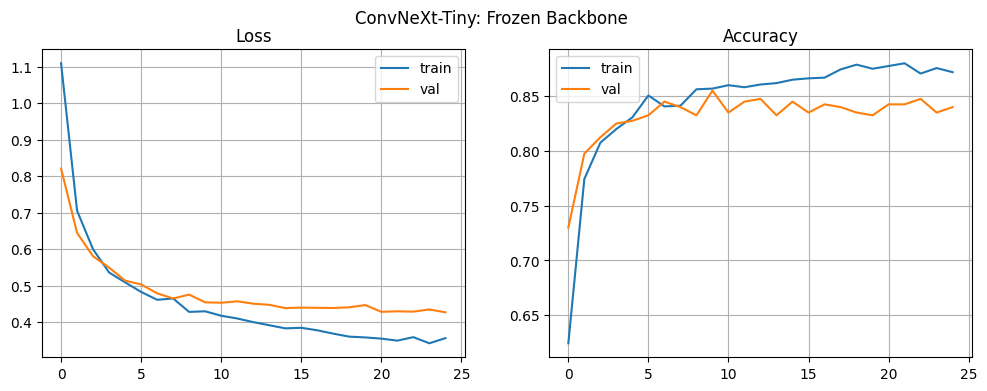

In [6]:
cnn_frozen = build_convnext_tiny(num_classes, freeze_backbone=True).to(DEVICE)
print("Trainable params (frozen):", sum(p.requires_grad for p in cnn_frozen.parameters()))

cnn_frozen, hist_frozen = fit(cnn_frozen, train_loader, val_loader, lr=1e-3, epochs=EPOCHS)
plot_history(hist_frozen, "ConvNeXt-Tiny: Frozen Backbone")


## Experiment 2: Partial Fine-Tuning

/tmp/ipykernel_23/2803352911.py:83: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Trainable params (partial): 35
AMP: Enabled (CUDA + GradScaler)


train:   0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_23/2803352911.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
eval:   0%|          | 0/13 [00:00<?, ?it/s]/tmp/ipykernel_23/2803352911.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/25 | train loss 0.7086 acc 0.7481 | val loss 0.4949 acc 0.8250


Epoch 2/25 | train loss 0.3937 acc 0.8581 | val loss 0.4921 acc 0.8225


...

Epoch 21/25 | train loss 0.0336 acc 0.9894 | val loss 0.8270 acc 0.8300


Epoch 22/25 | train loss 0.0483 acc 0.9869 | val loss 0.7225 acc 0.8500


Epoch 23/25 | train loss 0.0316 acc 0.9900 | val loss 0.7943 acc 0.8550


Epoch 24/25 | train loss 0.0267 acc 0.9938 | val loss 0.9084 acc 0.8175


Epoch 25/25 | train loss 0.0265 acc 0.9900 | val loss 0.9226 acc 0.8175


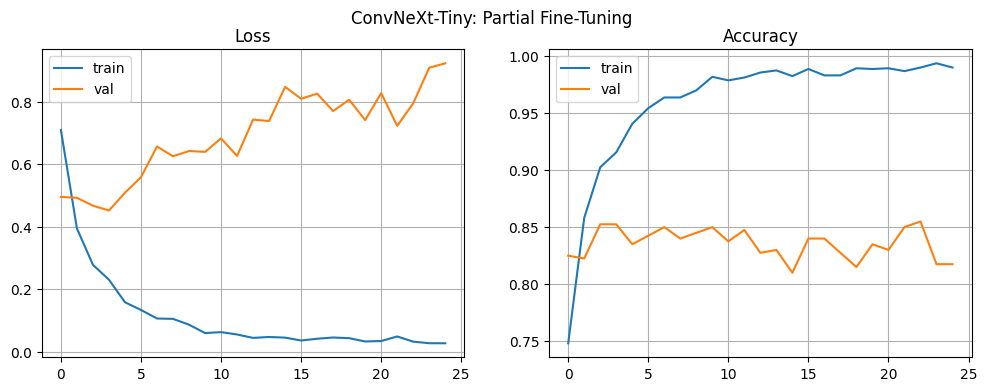

In [7]:
def unfreeze_last_convnext_blocks(model, n_blocks=2):
    # Freeze all
    for p in model.parameters():
        p.requires_grad = False

    # Unfreeze classifier head
    for p in model.classifier.parameters():
        p.requires_grad = True

    # Unfreeze last N feature modules
    for m in list(model.features.children())[-n_blocks:]:
        for p in m.parameters():
            p.requires_grad = True

    return model

cnn_model = build_convnext_tiny(num_classes, freeze_backbone=True)
cnn_model = unfreeze_last_convnext_blocks(cnn_model, n_blocks=2).to(DEVICE)

print("Trainable params (partial):", sum(p.requires_grad for p in cnn_model.parameters()))

cnn_model, hist_partial = fit(cnn_model, train_loader, val_loader, lr=3e-4, epochs=EPOCHS)
plot_history(hist_partial, "ConvNeXt-Tiny: Partial Fine-Tuning")


## Feature Detection Demo (Flat, Edge, Corner)

We will:
1. Generate **synthetic images** (flat / edge / corner)
2. Hook into ConvNeXt layers (early + mid)
3. Visualize feature maps

Goal:
- Show that early CNN layers behave like classical feature detectors.


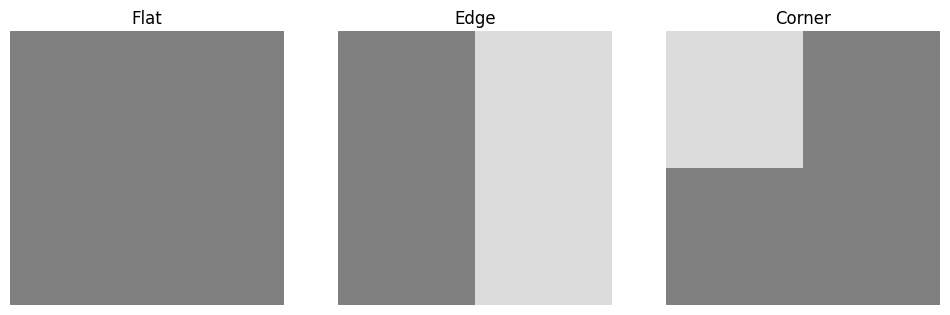

In [8]:
class ActivationHook:
    def __init__(self, module):
        self.out = None
        self.hook = module.register_forward_hook(self._hook_fn)
    def _hook_fn(self, module, inp, out):
        self.out = out.detach()
    def close(self):
        self.hook.remove()

def get_convnext_layers(model):
    # If needed, print(model.features) and adjust indices.
    return {
        "early": model.features[0],
        "mid":   model.features[2],
    }

def make_synthetic_flat_edge_corner(size=224):
    flat = np.full((size, size), 128, dtype=np.uint8)

    edge = np.full((size, size), 128, dtype=np.uint8)
    edge[:, size//2:] = 220

    corner = np.full((size, size), 128, dtype=np.uint8)
    corner[:size//2, :size//2] = 220

    def to_rgb(x):
        return np.stack([x,x,x], axis=-1)

    return to_rgb(flat), to_rgb(edge), to_rgb(corner)

def preprocess_np_rgb(np_img):
    pil = Image.fromarray(np_img)
    return val_tfms(pil).unsqueeze(0).to(DEVICE)

@torch.no_grad()
def forward_and_collect(model, hooks_dict, np_img):
    x = preprocess_np_rgb(np_img)
    _ = model(x)
    return {k: hooks_dict[k].out for k in hooks_dict.keys()}

def show_feature_maps(act, title, max_channels=16):
    fm = act[0]
    c = min(max_channels, fm.shape[0])
    f = fm[:c]

    f_min = f.amin(dim=(1,2), keepdim=True)
    f_max = f.amax(dim=(1,2), keepdim=True)
    f_norm = (f - f_min) / (f_max - f_min + 1e-6)

    grid = make_grid(f_norm.unsqueeze(1), nrow=8, padding=1)
    plt.figure(figsize=(14,4))
    plt.imshow(grid.permute(1,2,0).cpu(), cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.show()

flat_img, edge_img, corner_img = make_synthetic_flat_edge_corner(IMG_SIZE)

fig, ax = plt.subplots(1,3, figsize=(12,4))
ax[0].imshow(flat_img); ax[0].set_title("Flat"); ax[0].axis("off")
ax[1].imshow(edge_img); ax[1].set_title("Edge"); ax[1].axis("off")
ax[2].imshow(corner_img); ax[2].set_title("Corner"); ax[2].axis("off")
plt.show()


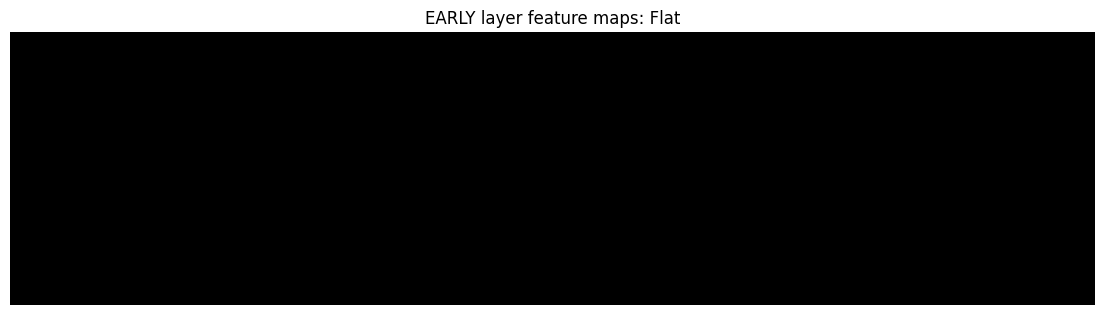

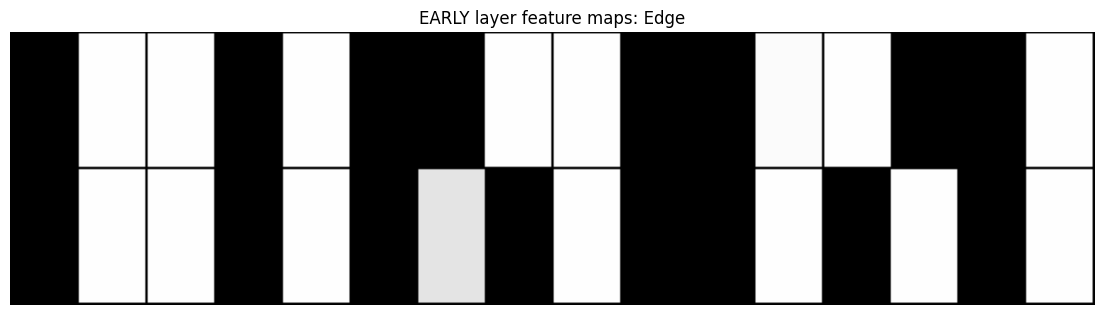

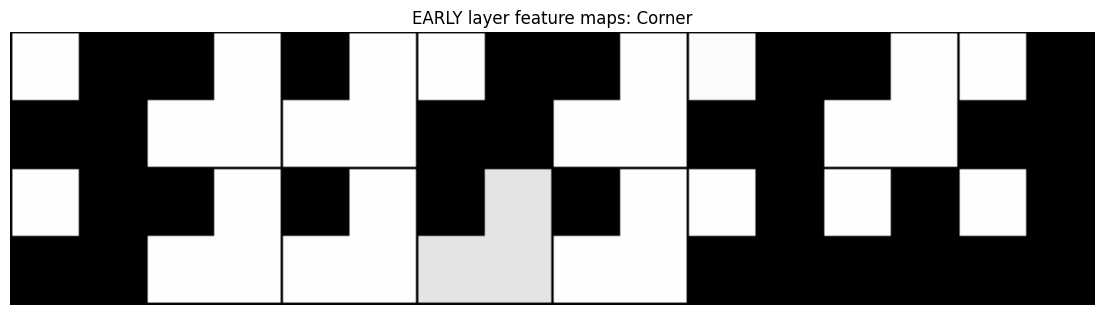

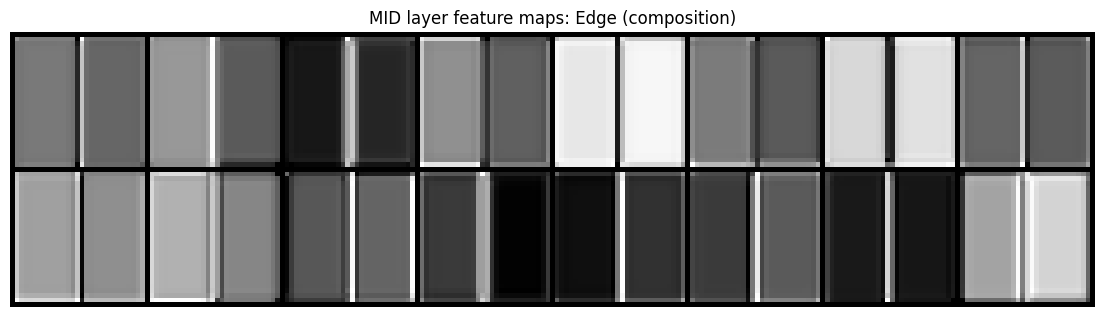

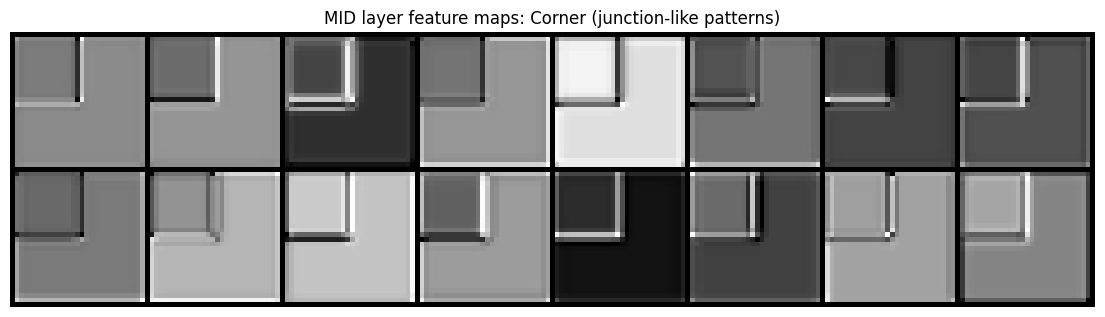

In [9]:
cnn_model.eval()
layers = get_convnext_layers(cnn_model)
hooks = {k: ActivationHook(v) for k,v in layers.items()}

acts_flat   = forward_and_collect(cnn_model, hooks, flat_img)
acts_edge   = forward_and_collect(cnn_model, hooks, edge_img)
acts_corner = forward_and_collect(cnn_model, hooks, corner_img)

show_feature_maps(acts_flat["early"],   "EARLY layer feature maps: Flat")
show_feature_maps(acts_edge["early"],   "EARLY layer feature maps: Edge")
show_feature_maps(acts_corner["early"], "EARLY layer feature maps: Corner")

show_feature_maps(acts_edge["mid"],     "MID layer feature maps: Edge (composition)")
show_feature_maps(acts_corner["mid"],   "MID layer feature maps: Corner (junction-like patterns)")


## Feature Matching Across Layers (Cosine Similarity)

- We compare the activation vector at the center location.
- This shows that deeper layers match **feature compositions**, not raw pixels.


### What this code is measuring
For each layer ("EARLY" and "MID"), we take the **activation vector** at the **center pixel location** of the feature map.

- A feature map tensor has shape: **(B, C, H, W)**
  - **B** = batch size  
  - **C** = number of channels (learned filters)  
  - **H, W** = spatial size of the feature map  

At a fixed location `(h, w)`, the model produces a vector of length **C**:
- `act[0, :, h, w]` → a **C-dimensional feature descriptor** for that location.

We then compute **cosine similarity** between descriptors from two different inputs (Flat vs Edge vs Corner):

- Cosine similarity range: **[-1, 1]**
  - **+1** → the two feature vectors point in the same direction (very similar representation)
  - **0**  → orthogonal (no consistent relationship)
  - **-1** → opposite direction (highly dissimilar representation)

### Why we use cosine similarity
Cosine similarity compares the **pattern of activations across channels** while being relatively insensitive to overall magnitude.  
This is a common way to ask:  
> “Does the model represent these two inputs similarly at this layer?”

### How to interpret the EARLY-layer results
Early layers typically detect **low-level primitives**:
- edges, gradients, texture-like patterns

Expected behavior:
- **Edge vs Flat** → usually **low similarity** (flat regions lack gradients)
- **Corner vs Flat** → usually **low similarity**
- **Edge vs Corner** → can be **moderate**, because corners include edges (but also have edge intersections)

If these early similarities are not distinct, it may mean:
- the center location is not informative for your synthetic pattern, or
- the chosen “early” layer is not shallow enough.

### How to interpret the MID-layer results
Mid layers represent **compositions** of primitives:
- edge combinations, junction-like patterns, simple motifs

Expected behavior:
- **Edge vs Flat** stays low (flat still lacks structure)
- **Corner vs Edge** may **diverge more** than in early layers, because mid layers begin encoding corner/junction structure as a distinct pattern
- Some similarity relationships can shift because mid layers are less “pixel-like” and more “pattern-like”

### What to conclude from EARLY vs MID comparison
If you see the similarity relationships **change across layers**, that is the key lesson:

- Early layers: “Are there edges or gradients here?”
- Mid layers: “Do these edges combine into meaningful local structures (like corners/junctions)?”

### Practical notes (important)
- The code compares only the **center location**. If the center is not exactly on the edge/corner, results can be misleading.
  - Optional improvement: compare multiple locations (edge region, corner region, flat region).
- Similarities are model- and layer-dependent. The goal is not a fixed number, but the **trend across layers**.

### Student task (recommended)
1. Record EARLY and MID similarities.
2. Explain in 2–3 sentences: **how the representation changes from primitives (early) to compositions (mid)**.
3. If results look unexpected, change the location (e.g., sample near the edge or corner boundary) and compare again.


In [10]:
def center_hw(act):
    _, _, H, W = act.shape
    return H//2, W//2

def spatial_vector(act, h, w):
    return act[0, :, h, w]

def cosine_at_center(actA, actB):
    h, w = center_hw(actA)
    vA = spatial_vector(actA, h, w)
    vB = spatial_vector(actB, h, w)
    return F.cosine_similarity(vA, vB, dim=0).item()

print("Cosine similarity at center (EARLY):")
print("Edge vs Corner:", cosine_at_center(acts_edge["early"], acts_corner["early"]))
print("Edge vs Flat  :", cosine_at_center(acts_edge["early"], acts_flat["early"]))
print("Corner vs Flat:", cosine_at_center(acts_corner["early"], acts_flat["early"]))

print("\nCosine similarity at center (MID):")
print("Edge vs Corner:", cosine_at_center(acts_edge["mid"], acts_corner["mid"]))
print("Edge vs Flat  :", cosine_at_center(acts_edge["mid"], acts_flat["mid"]))
print("Corner vs Flat:", cosine_at_center(acts_corner["mid"], acts_flat["mid"]))


Cosine similarity at center (EARLY):
Edge vs Corner: 0.6206144690513611
Edge vs Flat  : 0.6206144690513611
Corner vs Flat: 1.0

Cosine similarity at center (MID):
Edge vs Corner: 0.704386830329895
Edge vs Flat  : 0.7288355827331543
Corner vs Flat: 0.964608907699585


# Visualize Feature Maps from Multiple CNN Layers (ConvNeXt)
 - Shows feature maps for selected layers on ONE image
 - Works with any CNN if you set the layers dictionary correctly

### HOOK UTILITY (WHY IT EXISTS)
 This hook captures intermediate activations from a CNN layer during
 the forward pass, without modifying the model architecture.

 Why this matters:
 - CNNs learn hierarchical features (edges → patterns → semantics)
 - By default, PyTorch only returns the final output
 - Hooks allow us to "look inside" the network for interpretability

 Used for:
 - Feature map visualization
 - Feature similarity analysis
 - Grad-CAM and other explainability methods


True label: Healthy Leaf


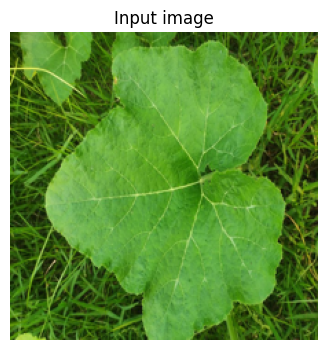

L0_stem activation shape: (1, 96, 56, 56)


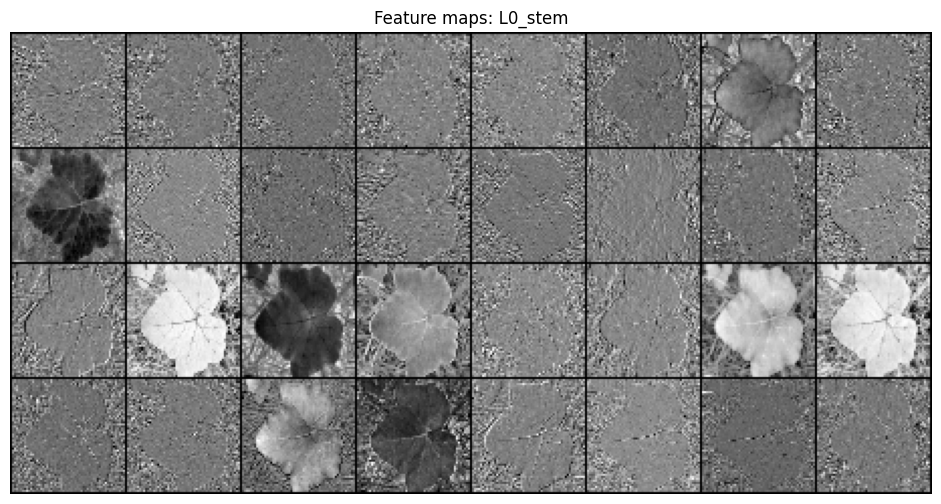

L2_mid activation shape: (1, 192, 28, 28)


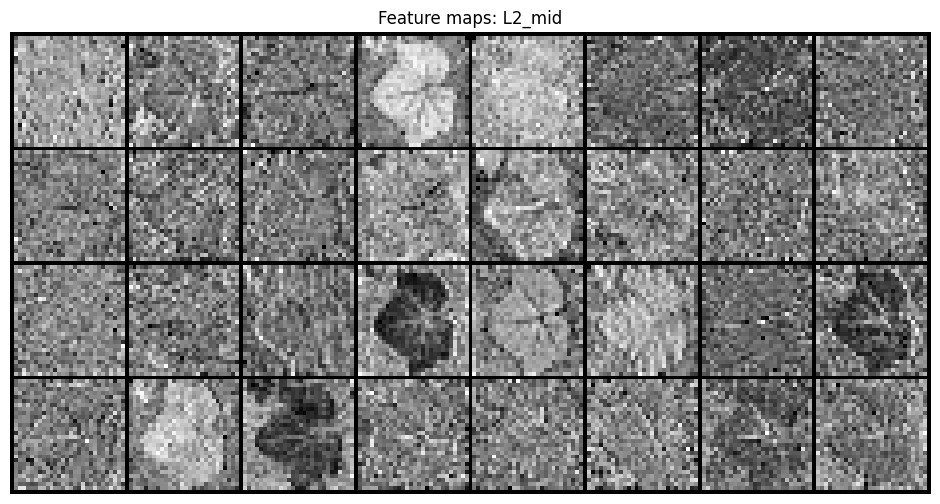

L4_late activation shape: (1, 384, 14, 14)


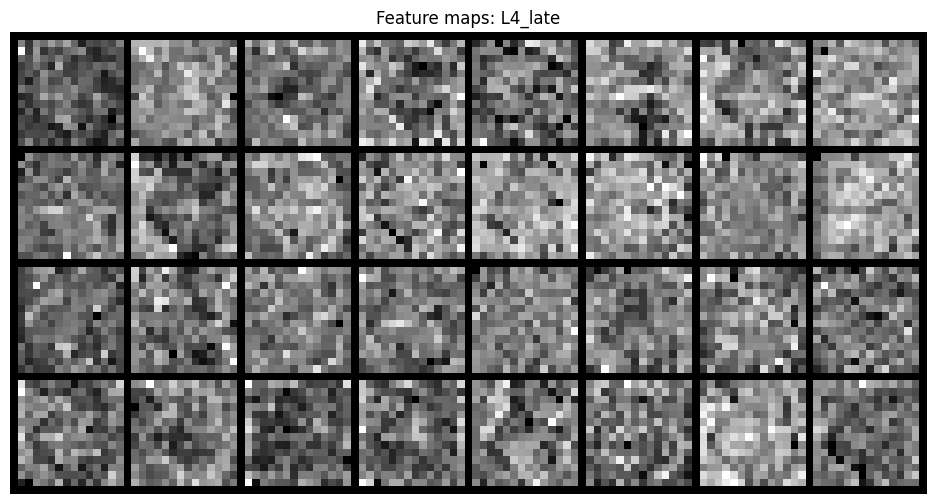

L_last activation shape: (1, 768, 7, 7)


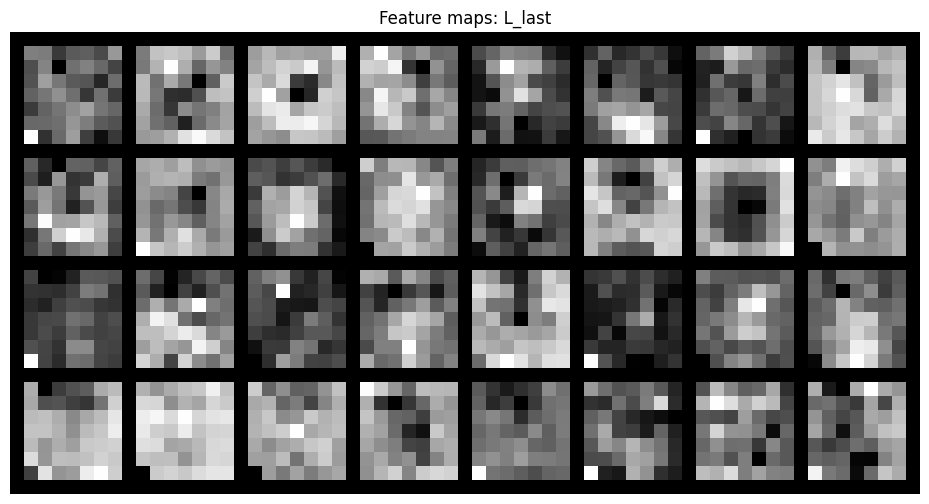

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from PIL import Image

# ----------------------------
# 1) Hook utility
# 1. register_forward_hook attaches a listener to a layer
# 2. During forward(), the layer output is passed to _hook_fn
# 3. The activation tensor is stored (detached from the graph)
# 4. close() removes the hook to avoid memory leaks
#
# Note:
# - detach() prevents unnecessary gradient tracking
# - Hooks are read-only observers (do NOT affect training)
# ---------------------------------------------------------------------
class ActivationHook:
    def __init__(self, module):
        self.out = None
        self.hook = module.register_forward_hook(self._hook_fn)
    def _hook_fn(self, module, inp, out):
        self.out = out.detach()
    def close(self):
        self.hook.remove()

# ----------------------------
# 2) Pick layers to visualize (ConvNeXt)
#    If you use a different CNN, update this mapping.
# ----------------------------
def get_convnext_vis_layers(model):
    """
    Returns a dictionary of layers to hook.
    Tip: print(model.features) if you want to choose different indices.
    """
    return {
        "L0_stem": model.features[0],
        "L2_mid":  model.features[2],
        "L4_late": model.features[4] if len(list(model.features.children())) > 4 else model.features[-2],
        "L_last":  model.features[-1],
    }

# ----------------------------
# 3) Helpers: preprocess and feature-map plotting
# ----------------------------
@torch.no_grad()
def preprocess_pil(pil_img, val_tfms, device):
    x = val_tfms(pil_img).unsqueeze(0).to(device)  # (1,C,H,W)
    return x

def _normalize_per_channel(fm):
    """
    fm: (C,H,W) tensor
    normalize each channel to [0,1] for visualization
    """
    f_min = fm.amin(dim=(1,2), keepdim=True)
    f_max = fm.amax(dim=(1,2), keepdim=True)
    return (fm - f_min) / (f_max - f_min + 1e-6)

def plot_feature_maps(act, title, max_channels=32, nrow=8):
    """
    act: activation tensor (1,C,H,W)
    Shows up to max_channels channels in a grid.
    """
    fm = act[0]  # (C,H,W)
    c = min(max_channels, fm.shape[0])
    fm = fm[:c]

    fm = _normalize_per_channel(fm)           # (C,H,W) -> [0,1] per channel
    grid = make_grid(fm.unsqueeze(1), nrow=nrow, padding=1)  # (C,1,H,W) -> grid

    plt.figure(figsize=(14, 6))
    plt.imshow(grid.permute(1,2,0).cpu(), cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.show()

# ----------------------------
# 4) Main: run one image and visualize feature maps per layer
# ----------------------------
def visualize_cnn_feature_maps(model, pil_img, val_tfms, device, max_channels=32, nrow=8):
    model.eval()

    # Setup hooks
    layers = get_convnext_vis_layers(model)
    hooks = {name: ActivationHook(layer) for name, layer in layers.items()}

    # Forward pass
    x = preprocess_pil(pil_img, val_tfms, device)
    with torch.no_grad():
        _ = model(x)

    # Show input
    np_img = np.array(pil_img.resize((224, 224)))
    plt.figure(figsize=(4,4))
    plt.imshow(np_img)
    plt.axis("off")
    plt.title("Input image")
    plt.show()

    # Plot activations layer-by-layer
    for name in layers.keys():
        act = hooks[name].out
        if act is None:
            print(f"[WARN] No activation captured for layer: {name}")
            continue
        print(f"{name} activation shape:", tuple(act.shape))
        plot_feature_maps(act, f"Feature maps: {name}", max_channels=max_channels, nrow=nrow)

    # Cleanup
    for h in hooks.values():
        h.close()

# ----------------------------
# 5) Example usage (uses your existing variables)
#    - cnn_model: trained ConvNeXt model
#    - val_base: your validation subset (PIL images, labels)
#    - val_tfms: validation transforms
# ----------------------------
idx = 0
pil_img, y_true = val_base[idx]   # PIL image from ImageFolder split
print("True label:", class_names[y_true])

visualize_cnn_feature_maps(
    model=cnn_model,
    pil_img=pil_img,
    val_tfms=val_tfms,
    device=DEVICE,
    max_channels=32,   # increase to 64 if you want more channels
    nrow=8
)


# Grad-CAM Explainability (CNN)

Grad-CAM highlights spatial regions that influence the predicted class most.

We will:
1. Choose a late spatial feature layer in ConvNeXt
2. Compute Grad-CAM heatmap
3. Overlay heatmap on the original image


## Grad-CAM Implementation

In [12]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.target_layer = target_layer
        self.grad = None
        self.act = None
        self.fwd_hook = target_layer.register_forward_hook(self._fwd_hook)
        self.bwd_hook = target_layer.register_full_backward_hook(self._bwd_hook)

    def _fwd_hook(self, module, inp, out):
        self.act = out

    def _bwd_hook(self, module, grad_input, grad_output):
        self.grad = grad_output[0]

    def close(self):
        self.fwd_hook.remove()
        self.bwd_hook.remove()

    def __call__(self, x, class_idx=None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        score = logits[:, class_idx].sum()
        score.backward(retain_graph=True)

        weights = self.grad.mean(dim=(2,3), keepdim=True)
        cam = (weights * self.act).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)

        cam = cam[0,0].detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-6)
        return cam, class_idx

def overlay_cam_on_image(np_rgb, cam, alpha=0.4):
    heat = (cam * 255).astype(np.uint8)
    heat = cv2.applyColorMap(heat, cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    overlay = (np_rgb.astype(np.float32) * (1-alpha) + heat.astype(np.float32) * alpha)
    return np.clip(overlay, 0, 255).astype(np.uint8)


## Grad-CAM on One Validation Image

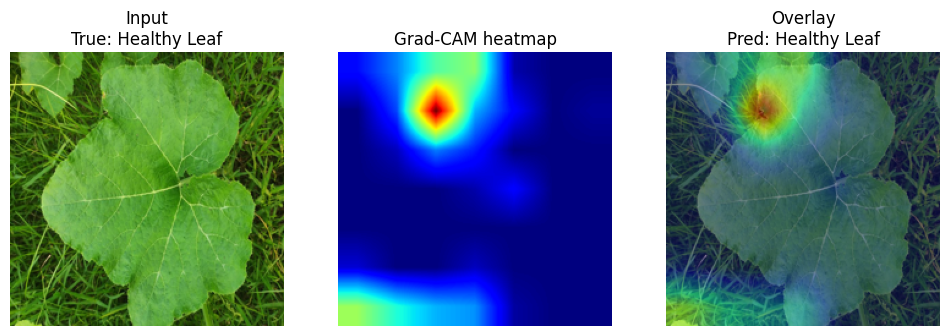

In [13]:
idx = 0
pil_img, y_true = val_base[idx]
np_img = np.array(pil_img.resize((IMG_SIZE, IMG_SIZE)))
x = val_tfms(pil_img).unsqueeze(0).to(DEVICE)

target_layer = cnn_model.features[-1]  # ConvNeXt late spatial features

cammer = GradCAM(cnn_model, target_layer)
cam, pred_idx = cammer(x)
cammer.close()

overlay = overlay_cam_on_image(np_img, cam)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(np_img); plt.axis("off"); plt.title(f"Input\nTrue: {class_names[y_true]}")
plt.subplot(1,3,2); plt.imshow(cam, cmap="jet"); plt.axis("off"); plt.title("Grad-CAM heatmap")
plt.subplot(1,3,3); plt.imshow(overlay); plt.axis("off"); plt.title(f"Overlay\nPred: {class_names[pred_idx]}")
plt.show()


# Robustness Tests + Explanation Drift

We apply controlled corruptions:
- noise
- blur
- occlusion
- color shift

We observe:
- prediction confidence changes
- Grad-CAM focus drift


## Robustness Helpers

In [14]:
def apply_corruption(np_rgb, kind="noise", severity=0.2):
    x = np_rgb.copy().astype(np.float32)
    if kind == "noise":
        sigma = 255 * severity
        n = np.random.normal(0, sigma, x.shape).astype(np.float32)
        x = x + n
    elif kind == "blur":
        k = int(1 + severity*20) | 1
        x = cv2.GaussianBlur(x, (k,k), 0)
    elif kind == "occlusion":
        h,w,_ = x.shape
        box = int(min(h,w) * severity)
        y0 = h//2 - box//2
        x0 = w//2 - box//2
        x[y0:y0+box, x0:x0+box] = 0
    elif kind == "color_shift":
        x = x * (1 + severity)
    return np.clip(x, 0, 255).astype(np.uint8)

@torch.no_grad()
def predict_np(model, np_rgb):
    pil = Image.fromarray(np_rgb)
    x = val_tfms(pil).unsqueeze(0).to(DEVICE)
    logits = model(x)
    probs = F.softmax(logits, dim=1)[0].detach().cpu().numpy()
    pred = int(probs.argmax())
    conf = float(probs[pred])
    return pred, conf

def gradcam_np(model, np_rgb, target_layer):
    pil = Image.fromarray(np_rgb)
    x = val_tfms(pil).unsqueeze(0).to(DEVICE)
    cammer = GradCAM(model, target_layer)
    cam, pred = cammer(x)
    cammer.close()
    return cam, pred


## Robustness Grid (Prediction + CAM)

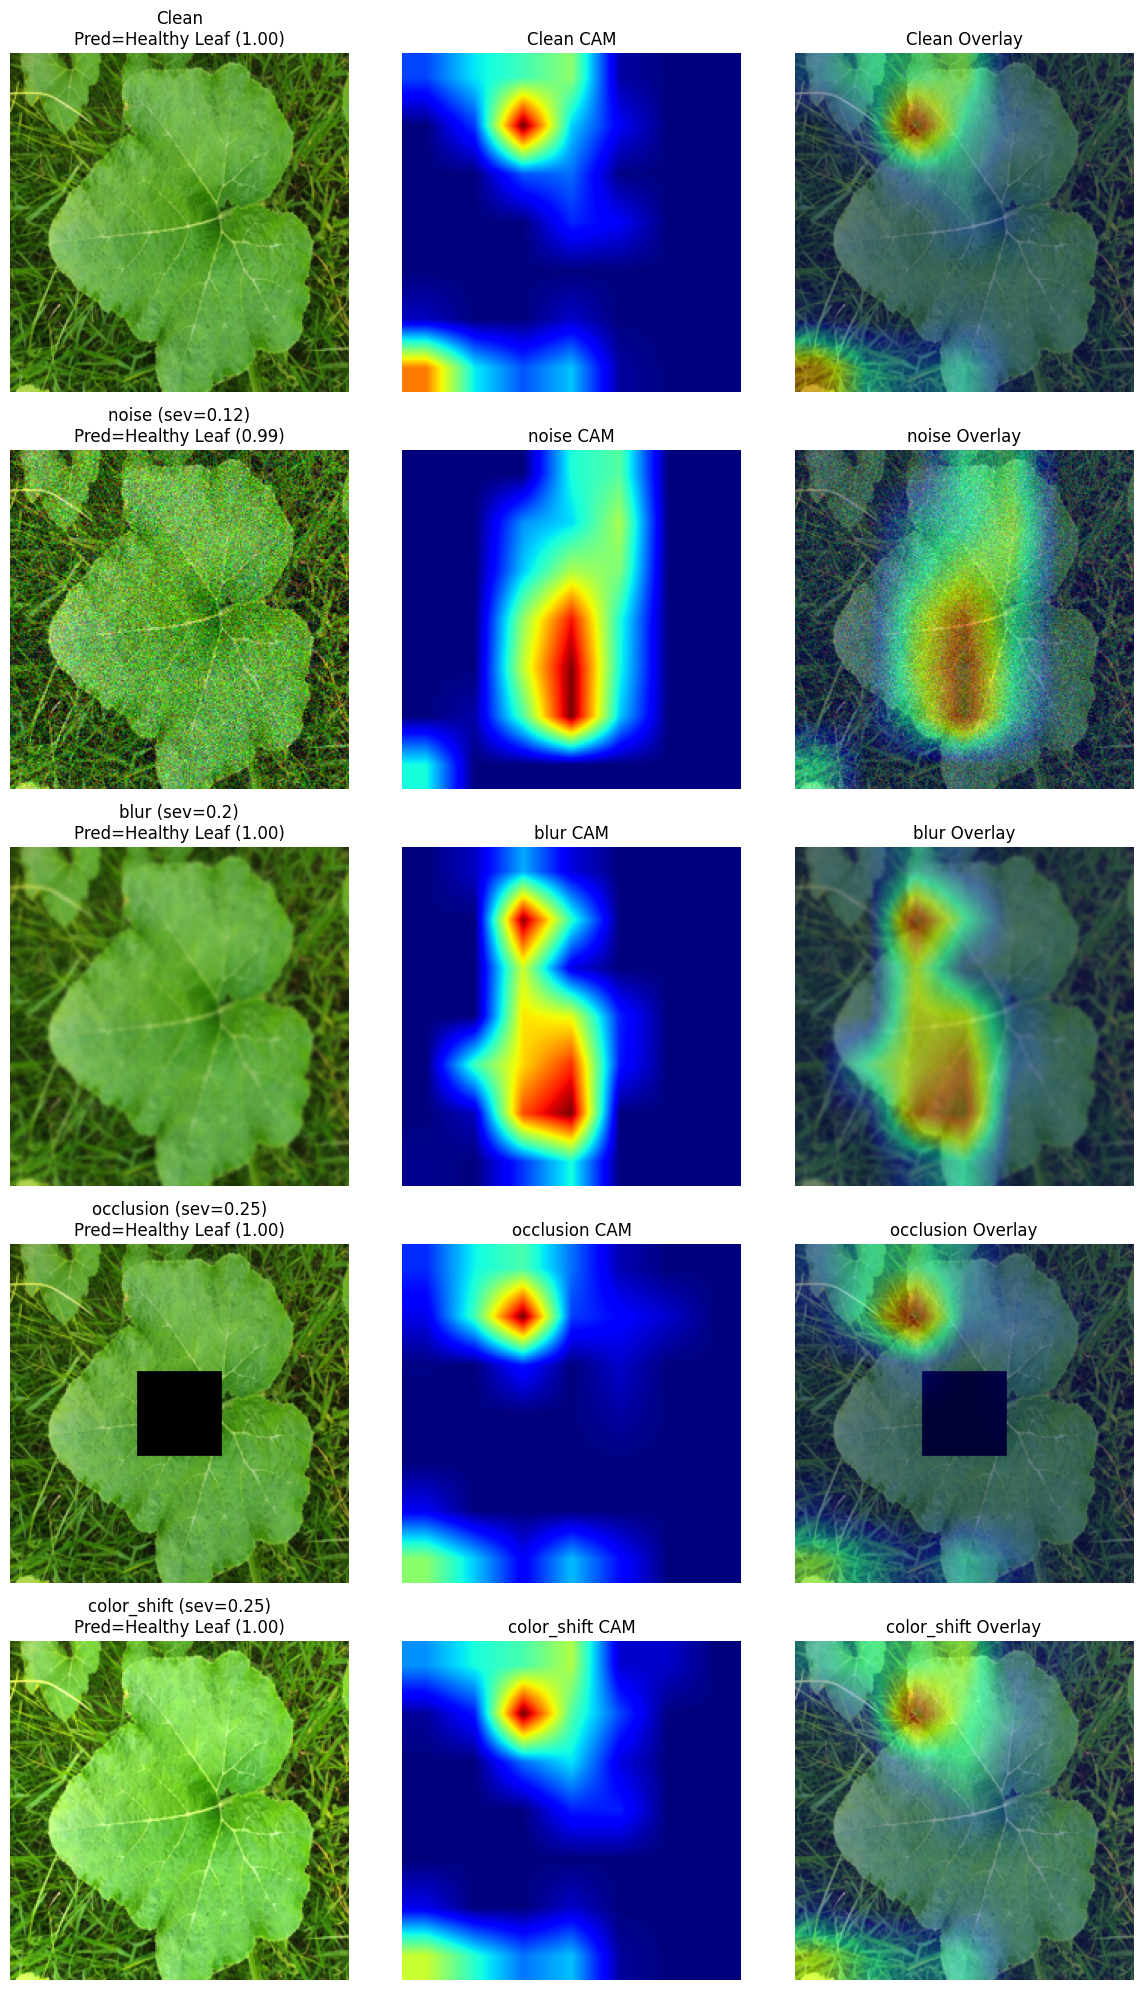

In [15]:
np_clean = np.array(pil_img.resize((IMG_SIZE, IMG_SIZE)))
pred_clean, conf_clean = predict_np(cnn_model, np_clean)
cam_clean, _ = gradcam_np(cnn_model, np_clean, target_layer)
overlay_clean = overlay_cam_on_image(np_clean, cam_clean)

tests = [
    ("noise", 0.12),
    ("blur", 0.20),
    ("occlusion", 0.25),
    ("color_shift", 0.25),
]

fig, ax = plt.subplots(len(tests)+1, 3, figsize=(12, 4*(len(tests)+1)))

ax[0,0].imshow(np_clean); ax[0,0].axis("off"); ax[0,0].set_title(f"Clean\nPred={class_names[pred_clean]} ({conf_clean:.2f})")
ax[0,1].imshow(cam_clean, cmap="jet"); ax[0,1].axis("off"); ax[0,1].set_title("Clean CAM")
ax[0,2].imshow(overlay_clean); ax[0,2].axis("off"); ax[0,2].set_title("Clean Overlay")

for i, (kind, sev) in enumerate(tests, start=1):
    np_cor = apply_corruption(np_clean, kind=kind, severity=sev)
    pred, conf = predict_np(cnn_model, np_cor)
    cam, _ = gradcam_np(cnn_model, np_cor, target_layer)
    overlay = overlay_cam_on_image(np_cor, cam)

    ax[i,0].imshow(np_cor); ax[i,0].axis("off"); ax[i,0].set_title(f"{kind} (sev={sev})\nPred={class_names[pred]} ({conf:.2f})")
    ax[i,1].imshow(cam, cmap="jet"); ax[i,1].axis("off"); ax[i,1].set_title(f"{kind} CAM")
    ax[i,2].imshow(overlay); ax[i,2].axis("off"); ax[i,2].set_title(f"{kind} Overlay")

plt.tight_layout()
plt.show()


# Failure Analysis (Misclassifications)

We collect a few misclassified validation images and diagnose them using Grad-CAM.


## Collect Misclassifications + Explain

Found misclassifications: 6
idx 10 true Powdery Mildew pred Downy Mildew conf 0.9928910732269287
idx 14 true Bacterial Leaf Spot pred Healthy Leaf conf 0.6151898503303528
idx 18 true Bacterial Leaf Spot pred Healthy Leaf conf 0.9935592412948608
idx 20 true Bacterial Leaf Spot pred Healthy Leaf conf 0.9934452772140503
idx 21 true Bacterial Leaf Spot pred Powdery Mildew conf 0.831176221370697
idx 25 true Bacterial Leaf Spot pred Powdery Mildew conf 0.9264849424362183


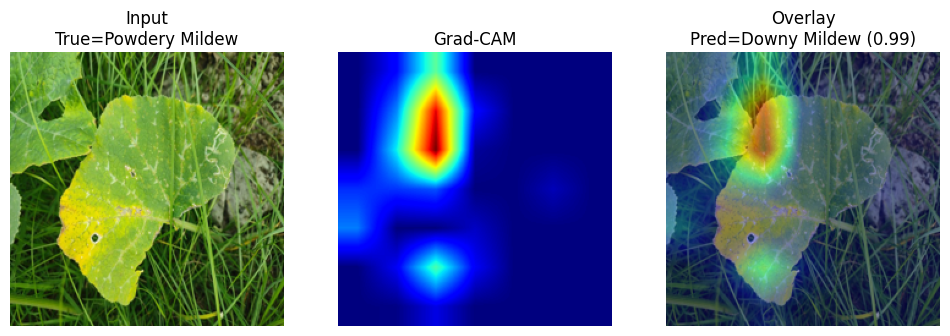

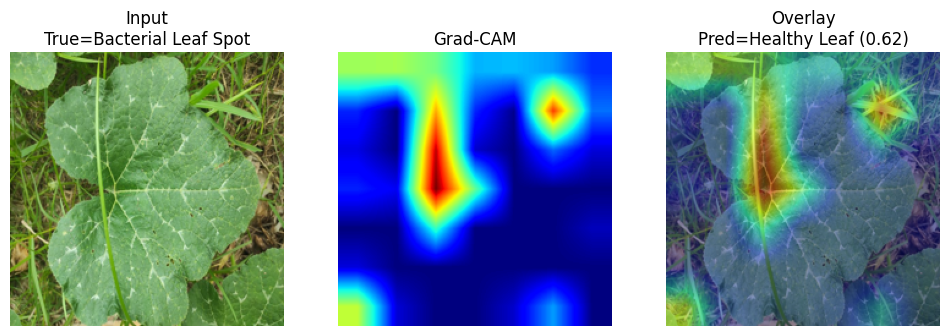

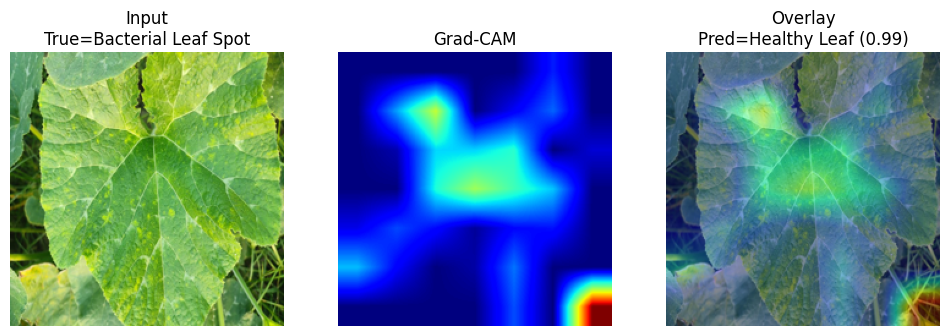

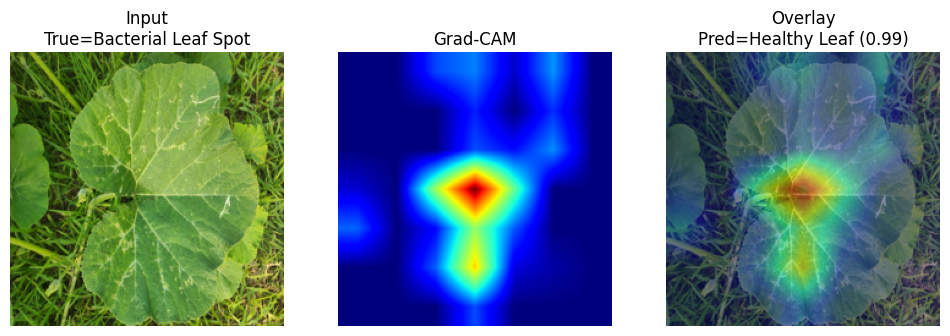

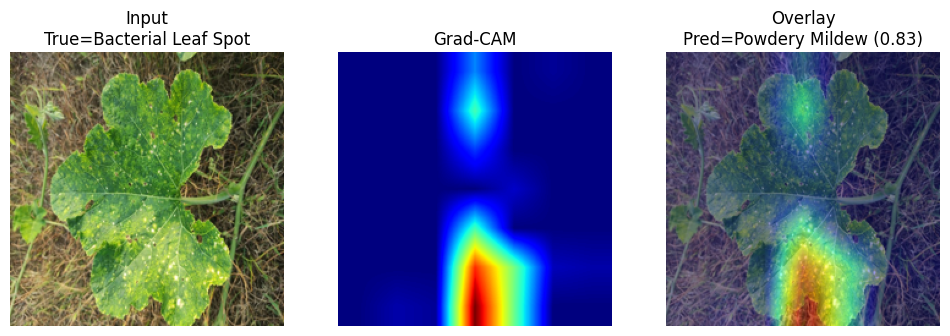

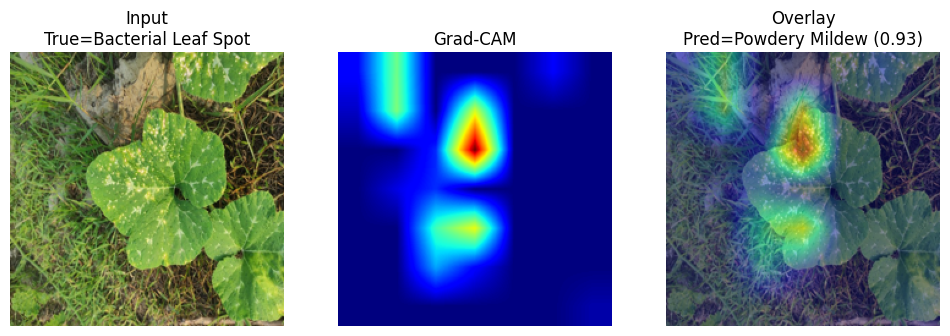

In [16]:
@torch.no_grad()
def collect_misclassified(model, base_subset, k=6):
    model.eval()
    misses = []
    for i in range(len(base_subset)):
        pil, y = base_subset[i]
        x = val_tfms(pil).unsqueeze(0).to(DEVICE)
        logits = model(x)
        pred = logits.argmax(dim=1).item()
        if pred != y:
            probs = F.softmax(logits, dim=1)[0].detach().cpu().numpy()
            conf = float(probs[pred])
            misses.append((i, pil, y, pred, conf))
        if len(misses) >= k:
            break
    return misses

misses = collect_misclassified(cnn_model, val_base, k=6)
print("Found misclassifications:", len(misses))
for m in misses:
    print("idx", m[0], "true", class_names[m[2]], "pred", class_names[m[3]], "conf", m[4])

for idx, pil, y, pred, conf in misses:
    np_img_m = np.array(pil.resize((IMG_SIZE, IMG_SIZE)))
    cam_m, _ = gradcam_np(cnn_model, np_img_m, target_layer)
    overlay_m = overlay_cam_on_image(np_img_m, cam_m)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(np_img_m); plt.axis("off"); plt.title(f"Input\nTrue={class_names[y]}")
    plt.subplot(1,3,2); plt.imshow(cam_m, cmap="jet"); plt.axis("off"); plt.title("Grad-CAM")
    plt.subplot(1,3,3); plt.imshow(overlay_m); plt.axis("off"); plt.title(f"Overlay\nPred={class_names[pred]} ({conf:.2f})")
    plt.show()


## Cleanup Hooks

In [17]:
for h in hooks.values():
    h.close()
print("Notebook finished. Hooks closed.")


Notebook finished. Hooks closed.
